# Оценка А/Б теста и кластеризация для магазина спортивных товаров

## Импорты

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import time
import seaborn as sns
import numpy as np
import warnings
import re

from sqlalchemy import create_engine, text
from catboost import CatBoostClassifier
from kmodes.kprototypes import KPrototypes
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, train_test_split, GroupShuffleSplit, GroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from scipy.stats import ttest_ind, t
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report, average_precision_score, roc_curve, f1_score
from scipy.stats import randint, loguniform, uniform
from pathlib import Path

## Заргузка данных

In [2]:
warnings.filterwarnings("ignore")

# Пути
DATA_DIR = Path("data")
DB_PATH = DATA_DIR / "shop_database.db"
LOST_CSV_PATH = DATA_DIR / "personal_data.csv.gz"

# Читаем из БД
engine = create_engine(f"sqlite:///{DB_PATH}")

with engine.connect() as conn:
    df_pers  = pd.read_sql(text("SELECT * FROM personal_data"), conn)
    df_coef  = pd.read_sql(text("SELECT * FROM personal_data_coeffs"), conn)
    df_purch = pd.read_sql(text("SELECT * FROM purchases"), conn)

# Читаем утерянные данные
df_lost = pd.read_csv(LOST_CSV_PATH, compression="gzip")

# Соберём в словарь для удобного вывода
dfs = {
    "personal_data": df_pers,
    "personal_data_coeffs": df_coef,
    "purchases": df_purch,
    "personal_data_lost": df_lost,
}

# 1) Сводка по размерам
summary = pd.DataFrame([
    {
        "table": name,
        "rows": df.shape[0],
        "cols": df.shape[1],
        "id_nunique": (df["id"].nunique() if "id" in df.columns else None),
    }
    for name, df in dfs.items()
]).set_index("table")

display(summary)

# 2) Печать размеров + превью
def show_df(name, df, n=3):
    print(f"\n{name}: {df.shape[0]:,} rows × {df.shape[1]} cols")
    display(df.head(n))

for name, df in dfs.items():
    show_df(name, df, n=3)

,rows,cols,id_nunique
table,,,
personal_data,89241,6,89241
personal_data_coeffs,104989,5,104989
purchases,786260,7,104989
personal_data_lost,15748,5,15748



personal_data: 89,241 rows × 6 cols


,id,gender,age,education,city,country
0,0,0,36,среднее,1201,32
1,4,0,35,среднее,1134,32
2,6,1,52,среднее,1188,32



personal_data_coeffs: 104,989 rows × 5 cols


,id,lbt_coef,ac_coef,sm_coef,personal_coef
0,0,5.078678,-0.307147,0.959027,0.5072
1,3,7.764766,-0.030225,0.794720,0.4304
2,4,4.569378,0.063693,0.820892,0.5072



purchases: 786,260 rows × 7 cols


,id,product,colour,cost,product_sex,base_sale,dt
0,0,"Велосипед горный женский Stern Mira 2.0 26""",белый/синий,13599,0.0,1,7
1,0,Стол Outventure,зелёный,1499,NaN,0,37
2,0,Набор Outventure: стол + 4 стула,бежевый,4799,NaN,0,37



personal_data_lost: 15,748 rows × 5 cols


,id,age,education,city,country
0,101492,32,среднее,1188,32
1,42690,20,высшее,1134,32
2,113001,27,среднее,1187,32


In [3]:
TARGET_COUNTRY = 32

# 1) Склеиваем профили (основные + утерянные), но сохраняем приоритет данных из БД
df_pers_ = df_pers.copy()
df_lost_ = df_lost.copy()

df_pers_["_src"] = 0   # приоритет выше
df_lost_["_src"] = 1

df_clients = pd.concat([df_pers_, df_lost_], ignore_index=True)

# если по id есть дубли, оставляем запись из БД
df_clients = (
    df_clients
    .sort_values(["id", "_src"])
    .drop_duplicates("id", keep="first")
    .drop(columns=["_src"])
)

# 2) Добавляем коэффициент — лучше LEFT JOIN, чтобы не потерять клиентов
df_clients = df_clients.merge(
    df_coef[["id", "personal_coef"]],
    on="id",
    how="left"
)

# 3) Фильтр по стране (строго по заданию)
df_clients = df_clients[df_clients["country"] == TARGET_COUNTRY].copy()

# 4) На всякий случай заполним personal_coef, если вдруг где-то не нашёлся
df_clients["personal_coef"] = df_clients["personal_coef"].fillna(df_clients["personal_coef"].median())

print("df_clients shape:", df_clients.shape, "| unique ids:", df_clients["id"].nunique())

# 5) Согласовываем покупки с этим списком клиентов
valid_ids = set(df_clients["id"].unique())
before = df_purch["id"].nunique()

df_purch = df_purch[df_purch["id"].isin(valid_ids)].copy()

after = df_purch["id"].nunique()
print(f"df_purch unique ids: before={before}, after={after}, dropped={before-after}")
print("df_purch shape:", df_purch.shape)


df_clients shape: (104437, 7) | unique ids: 104437
df_purch unique ids: before=104989, after=104437, dropped=552
df_purch shape: (780117, 7)


## Подготовка данных

### Данные о клиентах

In [4]:
df_clients.describe()

,id,gender,age,city,country,personal_coef
count,104437.000000,88786.000000,104437.000000,104437.000000,104437.0,104437.000000
mean,89079.702586,0.573401,38.026437,1138.033647,32.0,0.459032
std,51422.858371,0.494586,12.287700,167.056344,0.0,0.062008
min,0.000000,0.000000,5.000000,0.000000,32.0,0.257600
25%,44498.000000,0.000000,30.000000,1134.000000,32.0,0.430400
50%,89157.000000,1.000000,38.000000,1167.000000,32.0,0.468800
75%,133601.000000,1.000000,46.000000,1188.000000,32.0,0.507200
max,178004.000000,1.000000,77.000000,1213.000000,32.0,0.558400


In [5]:
df_clients.info()

<class 'pandas.core.frame.DataFrame'>
Index: 104437 entries, 0 to 104988
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   id             104437 non-null  int64  
 1   gender         88786 non-null   float64
 2   age            104437 non-null  int64  
 3   education      104437 non-null  object 
 4   city           104437 non-null  int64  
 5   country        104437 non-null  int64  
 6   personal_coef  104437 non-null  float64
dtypes: float64(2), int64(4), object(1)
memory usage: 6.4+ MB


[Text(0.5, 0, 'Возраст'), Text(0, 0.5, 'Кол-во')]

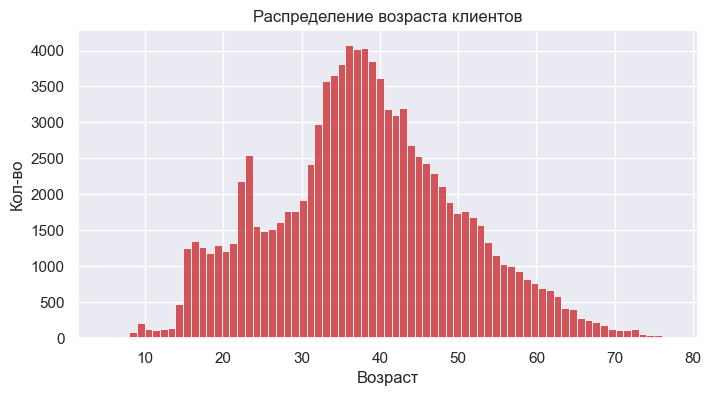

In [6]:
# Визуализируем некоторые распределени
sns.set_theme()
plt.rcParams['figure.figsize'] = [8, 4]
fig,ax = plt.subplots()
sns.histplot(df_clients['age'], bins=73, color='#C92228')
ax.set_title('Распределение возраста клиентов')
ax.set(xlabel='Возраст', ylabel='Кол-во')

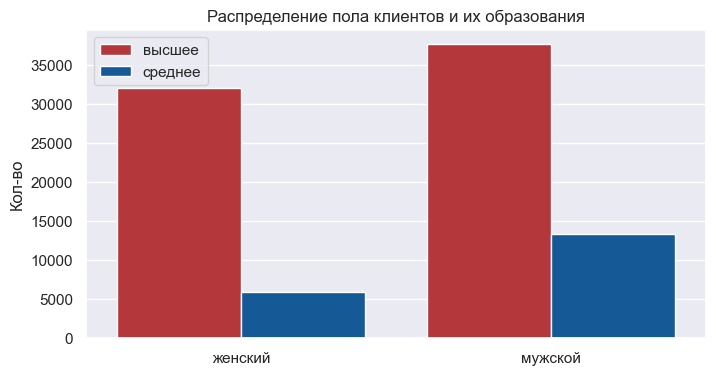

In [7]:
fig,ax = plt.subplots()
sns.countplot(x = df_clients['gender'],palette=['#C92228',"#005AAB"], hue=df_clients['education'])
ax.set_title('Распределение пола клиентов и их образования')
ax.set(xlabel=None, ylabel='Кол-во')
ax.set(xticklabels=['женский', 'мужской'])
ax.legend(title=None, loc='upper left', labels=['высшее', 'среднее'])

In [8]:
# Проверяем пропущенные значения и дубликаты

print('Дубликаты:', df_clients.duplicated().sum(), '\n')

print('Пропущенные значения:')
print(((df_clients.isna().sum() / len(df_clients)) * 100).sort_values(ascending=False))

Дубликаты: 0 

Пропущенные значения:
gender           14.986068
id                0.000000
age               0.000000
education         0.000000
city              0.000000
country           0.000000
personal_coef     0.000000
dtype: float64


In [9]:
# 1) Собираем клиентские признаки из покупок
purch_agg = (df_purch
    .groupby('id', as_index=False)
    .agg(
        orders_cnt=('cost', 'size'),
        spent_sum=('cost', 'sum'),
        spent_mean=('cost', 'mean'),
        sale_share=('base_sale', 'mean'),
        last_dt=('dt', 'max')
    )
)

max_dt = df_purch['dt'].max()
purch_agg['recency'] = max_dt - purch_agg['last_dt']

# (опционально) доли покупок по product_sex — полезно для пола
if 'product_sex' in df_purch.columns:
    tmp = df_purch[['id', 'product_sex']].copy()
    tmp['cnt'] = 1
    sex_share = (tmp.pivot_table(index='id', columns='product_sex', values='cnt', aggfunc='sum', fill_value=0))
    sex_share = sex_share.div(sex_share.sum(axis=1), axis=0).fillna(0)
    sex_share.columns = [f'prodsex_share_{c}' for c in sex_share.columns]
    sex_share = sex_share.reset_index()
    purch_agg = purch_agg.merge(sex_share, on='id', how='left')

# 2) Собираем таблицу для модели пола 
df_gender = df_clients.merge(purch_agg, on='id', how='left')

# заполняем пропуски по агрегатам покупок (если у клиента не было покупок)
agg_cols = [c for c in df_gender.columns if c in [
    'orders_cnt','spent_sum','spent_mean','sale_share','last_dt','recency'
] or str(c).startswith('prodsex_share_')]

for c in agg_cols:
    df_gender[c] = df_gender[c].fillna(0)

# 3) Делим на train (пол известен) / pred (пол потерян) 
train_mask = df_gender['gender'].notna()
train_df = df_gender.loc[train_mask].copy()
pred_df  = df_gender.loc[~train_mask].copy()

print("train_df:", train_df.shape, "| pred_df:", pred_df.shape)
print("missing gender after split:", pred_df['gender'].isna().mean())

# 4) X/y 
drop_cols = ['gender']  
X = train_df.drop(columns=drop_cols)
y = train_df['gender'].astype(int)

X_pred = pred_df.drop(columns=drop_cols)

for col in ['country']:
    if col in X.columns:
        X = X.drop(columns=[col])
        X_pred = X_pred.drop(columns=[col])

# 5) Preprocess: категориальные + числовые 
# Явно считаем education/city категориальными, даже если они вдруг числовые
force_cat = [c for c in ['education', 'city'] if c in X.columns]
obj_cat = X.select_dtypes(include=['object']).columns.tolist()
cat_cols = sorted(set(force_cat + obj_cat))
num_cols = [c for c in X.columns if c not in cat_cols and c != 'id']

preprocess = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_cols),
    ],
    remainder='drop'
)

# === 6) Модель (стабильный базлайн, обычно неплохой по F1) ===
clf = LogisticRegression(max_iter=3000, class_weight='balanced')

pipe = Pipeline(steps=[
    ('prep', preprocess),
    ('clf', clf)
])

# holdout-оценка (для контроля качества)
X_tr, X_val, y_tr, y_val = train_test_split(
    X.drop(columns=['id'], errors='ignore'),
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

pipe.fit(X_tr, y_tr)
pred_val = pipe.predict(X_val)

print("F1 (holdout):", round(f1_score(y_val, pred_val), 4))
print(classification_report(y_val, pred_val))

# === 7) Обучаемся на всех размеченных и предсказываем потерянный пол ===
pipe.fit(X.drop(columns=['id'], errors='ignore'), y)
gender_pred = pipe.predict(X_pred.drop(columns=['id'], errors='ignore'))

pred_out = pred_df[['id']].copy()
pred_out['gender_pred'] = gender_pred

# аккуратно заполняем в df_clients
df_clients = df_clients.merge(pred_out, on='id', how='left')
df_clients['gender'] = df_clients['gender'].fillna(df_clients['gender_pred'])
df_clients = df_clients.drop(columns=['gender_pred'])

print("Missing gender after fill:", df_clients['gender'].isna().sum())
df_clients['gender'] = df_clients['gender'].astype(int)
df_clients.head()


train_df: (88786, 15) | pred_df: (15651, 15)
missing gender after split: 1.0
F1 (holdout): 0.9467
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      7576
           1       0.95      0.94      0.95     10182

    accuracy                           0.94     17758
   macro avg       0.94      0.94      0.94     17758
weighted avg       0.94      0.94      0.94     17758

Missing gender after fill: 0


,id,gender,age,education,city,country,personal_coef
0,0,0,36,среднее,1201,32,0.5072
1,3,1,31,среднее,1134,32,0.4304
2,4,0,35,среднее,1134,32,0.5072
3,6,1,52,среднее,1188,32,0.4304
4,7,0,37,среднее,1198,32,0.5072


### Данные о покупках

In [10]:
df_purch.describe()

,id,cost,product_sex,base_sale,dt
count,780117.000000,780117.000000,467540.000000,780117.000000,780117.000000
mean,89066.851447,5412.478205,0.576190,0.356268,25.122362
std,51411.987985,10399.469604,0.494161,0.478896,17.298268
min,0.000000,-30.000000,0.000000,0.000000,0.000000
25%,44389.000000,1499.000000,0.000000,0.000000,10.000000
50%,89390.000000,2999.000000,1.000000,0.000000,22.000000
75%,133501.000000,5599.000000,1.000000,1.000000,40.000000
max,178004.000000,446420.000000,1.000000,1.000000,58.000000


In [11]:
df_purch.info()

<class 'pandas.core.frame.DataFrame'>
Index: 780117 entries, 0 to 786259
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   id           780117 non-null  int64  
 1   product      780117 non-null  object 
 2   colour       660936 non-null  object 
 3   cost         780117 non-null  int64  
 4   product_sex  467540 non-null  float64
 5   base_sale    780117 non-null  int64  
 6   dt           780117 non-null  int64  
dtypes: float64(1), int64(4), object(2)
memory usage: 47.6+ MB


[Text(0.5, 0, 'Стоимость'), Text(0, 0.5, 'Кол-во')]

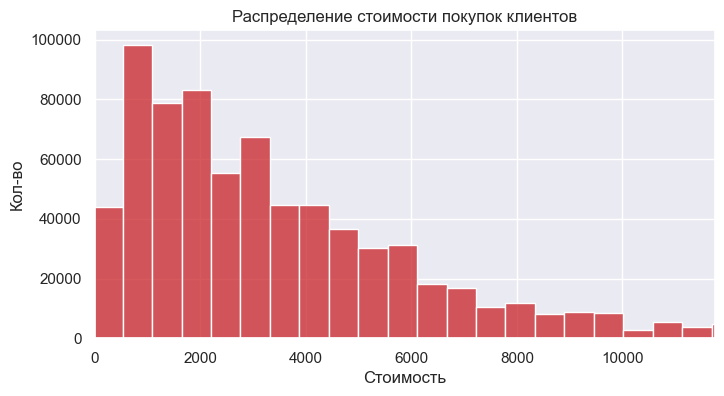

In [12]:
def get_outliers(data):
    q25 = data.quantile(0.25)
    q75 = data.quantile(0.75)
    iqr = q75 - q25
    boundaries = (q25 - 1.5 * iqr, q75 + 1.5 * iqr)
    return boundaries

fig,ax = plt.subplots()
ax.set_xlim(0,get_outliers(df_purch['cost'])[1])
sns.histplot(df_purch['cost'], bins=800, color='#C92228')
ax.set_title('Распределение стоимости покупок клиентов')
ax.set(xlabel='Стоимость', ylabel='Кол-во')

[[Text(0, 0, 'женcкий'), Text(1, 0, 'мужской')]]

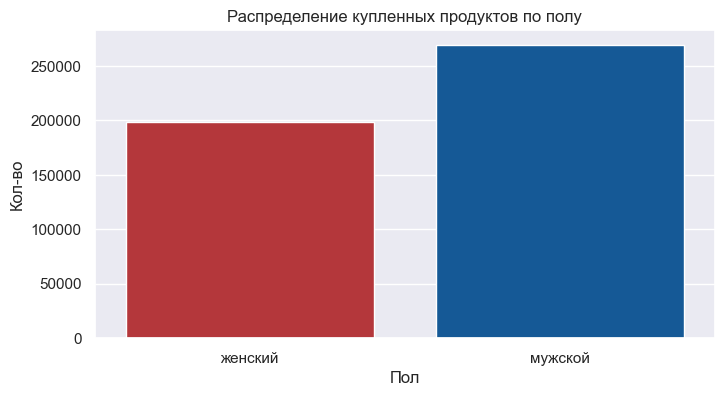

In [13]:
fig,ax = plt.subplots()
sns.countplot(x = df_purch['product_sex'],palette=['#C92228',"#005AAB"])
ax.set_title('Распределение купленных продуктов по полу')
ax.set(xlabel='Пол', ylabel='Кол-во')
ax.set(xticklabels=['женcкий', 'мужской'])

In [14]:
# Проверяем пропущенные значения и дубликаты

print('Дубликаты:',df_purch.duplicated().sum(), '\n')
print('Пропущенные значения:')
print(((df_purch.isna().sum() / len(df_purch)) * 100).sort_values(ascending=False))

Дубликаты: 0 

Пропущенные значения:
product_sex    40.067964
colour         15.277324
id              0.000000
product         0.000000
cost            0.000000
base_sale       0.000000
dt              0.000000
dtype: float64


In [15]:
# Проверяем товары где не заполнен признак product_sex
df_purch['product'][df_purch['product_sex'].isnull()].apply(lambda x: x.split()[0:3]).value_counts().head(50)

product
[Кроссовки, для, мальчиков]          7174
[Кроссовки, для, девочек]            4898
[Велосипед, горный, Stern]           4163
[Футболка, для, мальчиков]           4011
[Спортивный, топ, бра]               3313
[Шорты, для, мальчиков]              3264
[Брюки, для, мальчиков]              2800
[Сандалии, для, девочек]             2635
[Сандалии, для, мальчиков]           2553
[Спальный, мешок, Outventure]        2299
[Сабо, Crocs, Crocband]              2260
[Сумка, на, пояс]                    2138
[Бутсы, для, мальчиков]              2004
[Куртка, утепленная, для]            1999
[Палатка, 2-местная, Outventure]     1906
[Рюкзак, Demix]                      1894
[Полуботинки, для, мальчиков]        1806
[Кеды, для, мальчиков]               1775
[Велосипед, горный, Denton]          1729
[Кресло, кемпинговое, Outventure]    1698
[Сумка, FILA]                        1684
[Палатка, 3-местная, Outventure]     1662
[Солнцезащитные, очки, Kappa]        1607
[Палатка, 4-местная, Outve

In [16]:
# Создадим новые категории для признака product_sex
def infer_product_sex(name: str):
    n = str(name).lower()
    # мужское
    if any(word in n for word in ['мужск']) and 'детск' not in n:
        return 1
    # женское
    elif any(word in n for word in ['женск']) and 'детск' not in n:
        return 0
    # детское (отдельная категория)
    elif any(word in n for word in ['мальчик', 'девоч']):
        return 2
    # женские товары по назначению
    elif any(word in n for word in ['бра', 'топ']):
        return 0
    # остальное — унисекс
    else:
        return 3
    

df_purch['product_sex'] = df_purch.apply(
    lambda row: infer_product_sex(row['product']) if pd.isna(row['product_sex']) else row['product_sex'],
    axis=1
)

df_purch['product_sex'].value_counts()

product_sex
1.0    269573
3.0    240177
0.0    202975
2.0     67392
Name: count, dtype: int64

In [17]:
# Заполняем пропущенное значение признака цвет товара значением 'другой'
df_purch['colour'] = df_purch['colour'].fillna('другой')
df_purch.head()

,id,product,colour,cost,product_sex,base_sale,dt
0,0,"Велосипед горный женский Stern Mira 2.0 26""",белый/синий,13599,0.0,1,7
1,0,Стол Outventure,зелёный,1499,3.0,0,37
2,0,Набор Outventure: стол + 4 стула,бежевый,4799,3.0,0,37
3,3,Бутсы мужские GSD Astro,белый,1599,1.0,0,13
4,3,Мяч футбольный PUMA TEAMFINAL 21.2 FIFA QUALIT...,мультицвет,7199,3.0,0,27


In [18]:
# 1. Цвет
df_purch['colour'] = df_purch['colour'].replace(['чёрный'], 'черный')

# Берём первый цвет, если через "/", и приводим к нижнему регистру
df_purch['colour'] = df_purch['colour'].apply(lambda x: str(x).split('/')[0].lower().strip())

# Оставляем только кириллицу, дефисы и пробелы
df_purch['colour'] = df_purch['colour'].apply(lambda x: re.sub(r'[^а-я\- ]', ' ', x))
df_purch['colour'] = df_purch['colour'].str.replace(r'\s+', ' ', regex=True).str.strip()

# Схлопываем редкие цвета в "другой" (например, <1% встречаемости)
vc = df_purch['colour'].value_counts(normalize=True)
rare_colours = vc[vc < 0.01].index
df_purch['colour'] = df_purch['colour'].replace(rare_colours, 'другой')


# 2. Название продукта
df_purch['product'] = df_purch['product'].apply(lambda x: " ".join(re.findall('[А-Яа-я]{3,20}', str(x))).lower())

# Стоп-слова и размеры
STOP_TOKENS = {
    "для","и","в","на","из","со","с","от","до","по","без",
    "детский","детские","детская","детское","детских",
    "мужской","мужские","мужская","мужское","мужских",
    "женский","женские","женская","женское","женских",
    "мальчик","мальчика","мальчику","мальчиком","мальчиков","мальчики",
    "девочка","девочки","девочке","девочкой","девочках","девочек"
}

SIZE_TOKENS = {"xxs","xs","s","m","l","xl","xxl","xxxl",
               "44","46","48","50","52","54","56","58","60",
               "one","size","ос","см"}

def clean_product_tokens(name: str) -> str:
    tokens = [t for t in name.split() if t not in STOP_TOKENS and t not in SIZE_TOKENS]
    return " ".join(tokens)

df_purch['product'] = df_purch['product'].apply(clean_product_tokens)

min_count = 100
vc = df_purch['product'].value_counts()
rare_products = vc[vc < min_count].index

df_purch['product'] = df_purch['product'].replace(rare_products, 'другой')


## Оценка А/Б теста

### Подготовка данных

In [19]:
# Загружаем файлы которые содержат id клиентов участвовавших в A/B тесте
with open('data/ids_first_company_positive.txt') as f:
    positive = f.read()

elem_list = re.split(';|,| ', positive)

positive_id = []

for i in elem_list:
    if i.isdigit():
        positive_id.append(int(i))

len(positive_id)

4964

In [20]:
with open('data/ids_first_company_negative.txt') as f:
    negative = f.read()

elem_list = re.split(';|,| ', negative)

negative_id = []

for i in elem_list:
    if i.isdigit():
        negative_id.append(int(i))

len(negative_id)

4961

In [21]:
df_purch.head()

,id,product,colour,cost,product_sex,base_sale,dt
0,0,велосипед горный,белый,13599,0.0,1,7
1,0,стол,другой,1499,3.0,0,37
2,0,набор стол стула,бежевый,4799,3.0,0,37
3,3,бутсы,белый,1599,1.0,0,13
4,3,мяч футбольный,мультицвет,7199,3.0,0,27


In [22]:
# Выбираем покупки которые были совершены во время проведения первой рекламной компании
df_ab_window = df_purch[(df_purch['dt'] >= 5) & (df_purch['dt'] < 17)]

# объединяем значения
revenue = df_ab_window.groupby('id', as_index=False)['cost'].sum()

# все клиенты treatment / control
treat_all = pd.DataFrame({'id': positive_id}).merge(revenue, on='id', how='left').fillna({'cost':0})
ctrl_all  = pd.DataFrame({'id': negative_id}).merge(revenue, on='id', how='left').fillna({'cost':0})

### Проверка гипотез



**Нулевая гипотеза (H₀):**  
Средняя выручка на клиента в группе с персональной скидкой равна средней выручке на клиента в контрольной группе

**Альтернативная гипотеза (H₁):**  
Средняя выручка на клиента в группе с персональной скидкой выше, чем в контрольной группе

In [23]:
# Перед проведением A/B теста проверяем работу статистического критерия t-test
treat_vals = treat_all['cost'].values
ctrl_vals  = ctrl_all['cost'].values
combined = np.concatenate([treat_vals, ctrl_vals])

n_treat = len(treat_vals)
n_ctrl  = len(ctrl_vals)

n_iter = 10000
p_values = []

for _ in range(n_iter):
    # случайная перестановка
    np.random.shuffle(combined)
    pseudo_treat = combined[:n_treat]
    pseudo_ctrl  = combined[n_treat:]
    
    # t-test для случайных групп
    _, p = ttest_ind(pseudo_treat, pseudo_ctrl, equal_var=False)
    p_values.append(p)

p_values = np.array(p_values)

# Доля «ложных срабатываний» при уровне значимости 0.05
false_positive_rate = (p_values < 0.05).mean()

print("Среднее p-value:", p_values.mean())
print("Доля ложных срабатываний (alpha=0.05):", false_positive_rate)

Среднее p-value: 0.4982490710961065
Доля ложных срабатываний (alpha=0.05): 0.0491


#### Проверка корректности t-test с помощью Монте-Карло

Мы случайно перемешивали и делили выборку на treatment/control, вычисляя p-value t-test (10 000 раз).  
Распределение полученных p-values оказалось близким к равномерному (см. график ниже).  

Это подтверждает, что t-test на наших данных работает корректно:  
- не завышает и не занижает вероятность ошибки первого рода,  
- его можно использовать для проверки гипотез о разнице в ARPU.

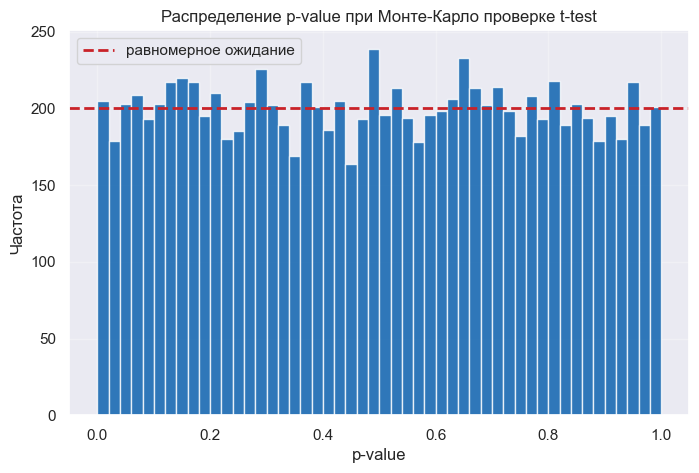

In [24]:
plt.figure(figsize=(8,5))
plt.hist(
    p_values,
    bins=50,
    edgecolor='white',
    color='#005AAB',  
    alpha=0.8
)
plt.axhline(
    y=len(p_values)/50,
    color='#C92228', 
    linestyle='--',
    linewidth=2,
    label='равномерное ожидание'
)
plt.xlabel("p-value")
plt.ylabel("Частота")
plt.title("Распределение p-value при Монте-Карло проверке t-test")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



In [25]:
# t-test (Welch), H1: ARPU_treat > ARPU_ctrl
x = treat_all['cost'].values
y = ctrl_all['cost'].values

# односторонний тест (Welch: equal_var=False)
t_stat, p_two_sided = ttest_ind(x, y, equal_var=False)
# переводим в "greater": делим пополам и учитываем знак статистики
p_one_sided = p_two_sided / 2 if t_stat > 0 else 1 - (p_two_sided / 2)

arpu_t = x.mean()
arpu_c = y.mean()
diff   = arpu_t - arpu_c
lift   = diff / arpu_c if arpu_c != 0 else np.nan

print(f"ARPU_treat: {arpu_t:,.2f}")
print(f"ARPU_ctrl : {arpu_c:,.2f}")
print(f"Разница    : {diff:,.2f}  (lift: {lift:.2%})")
print(f"t-stat     : {t_stat:.3f}")
print(f"p-value (H1: treat > control): {p_one_sided:.6f}")

# 95% CI для разницы средних по формуле Welch
n1, n2 = len(x), len(y)
s1, s2 = x.var(ddof=1), y.var(ddof=1)
se = np.sqrt(s1/n1 + s2/n2)
# степени свободы по Welch–Satterthwaite
df = (s1/n1 + s2/n2)**2 / ((s1**2)/((n1**2)*(n1-1)) + (s2**2)/((n2**2)*(n2-1)))
t_crit = t.ppf(0.975, df)
ci_low, ci_high = diff - t_crit*se, diff + t_crit*se
print(f"95% CI разницы: [{ci_low:,.2f}; {ci_high:,.2f}]")

# вывод при alpha=0.05
alpha = 0.05
if p_one_sided < alpha:
    print("⬆️  Отвергаем H0: персональная скидка статистически повышает ARPU.")
else:
    print("⭕ Не отвергаем H0: статистически значимого роста ARPU не выявлено.")


ARPU_treat: 26,573.12
ARPU_ctrl : 22,270.58
Разница    : 4,302.54  (lift: 19.32%)
t-stat     : 5.339
p-value (H1: treat > control): 0.000000
95% CI разницы: [2,723.01; 5,882.06]
⬆️  Отвергаем H0: персональная скидка статистически повышает ARPU.


### Вывод
- Разница статистически значима (p-value ≪ 0.05).
- Персональная скидка **существенно увеличивает выручку на клиента**.
- Минимальный ожидаемый прирост ARPU (по нижней границе CI) ≈ **2,783 руб.**, максимальный ≈ **5,954 руб.**
- С точки зрения бизнеса кампания была **успешной** и принесла дополнительную ценность.


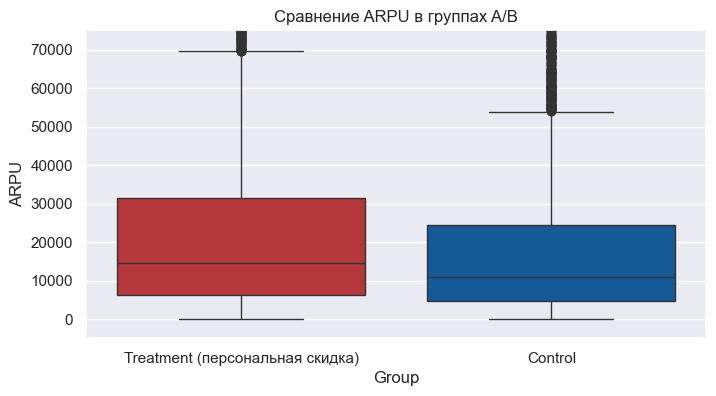

In [29]:

plot_df = pd.DataFrame({
    "ARPU": list(treat_all['cost']) + list(ctrl_all['cost']),
    "Group": ["Treatment (персональная скидка)"] * len(treat_all) + ["Control"] * len(ctrl_all)
})

plt.figure()
sns.boxplot(
    data=plot_df,
    x="Group",
    y="ARPU",
    palette=['#C92228',"#005AAB"],
)

plt.ylim(-5000, 75000)  # ограничение оси
plt.ylabel("ARPU")
plt.title("Сравнение ARPU в группах A/B")
plt.show()






## Кластеризация

In [ ]:
# Создаем новую таблицу с группировкой по id
df_g = df_purch.groupby('id', as_index=False).agg({'cost':'sum',
                                                   'product': pd.Series.mode,
                                                   'colour': pd.Series.mode,
                                                   'product_sex': pd.Series.mode,
                                                   'base_sale':'mean',
                                                   'dt':'max'
                                                   })

# Изменяем названия признаков
dict = {'cost': 'cost_sum',
        'product': 'product_mode',
        'colour': 'color_mode',
        'product_sex': 'product_sex_mode',
        'base_sale': 'best_sale_mean',
        'dt': 'dt_max'}

df_g = df_g.rename(columns=dict)

# Преобразуем элементы признаков, которые состоят из списков в строку
mode_columns = ['product_mode', 'color_mode', 'product_sex_mode']

for column in mode_columns:
    df_g[column] = df_g[column].apply(lambda x: x[0] if type(x) == np.ndarray else x)

# Объединяем датафрейм с данными о клиентах
df = pd.merge(left=df_clients, right=df_g, on='id', how='inner')
df = df.drop(columns=['id'])
num_columns = ['age', 'personal_coef','cost_sum', 'best_sale_mean','dt_max']
scaler = StandardScaler()
df[num_columns] = scaler.fit_transform(df[num_columns])

# Выбираем оптимальное количество кластеров с помощью метода локтя
n_clusters = list(range(2,8))
cost = []

for n in n_clusters:
    kproto = KPrototypes(n_clusters=n, init='Cao', n_jobs=-1)
    kproto.fit_predict(df, categorical=[0,2,3,4,7,8,9])
    cost.append(kproto.cost_)

sns.lineplot(x=n_clusters, y=cost, color='#C92228')

In [ ]:
kproto = KPrototypes(n_clusters=4, init='Cao', n_jobs=-1)
kproto.fit_predict(df, categorical=[0,2,3,4,7,8,9])

# Преобразуем числовые признаки датафрейма к двумерной таблице с помощью TSNE, для последующей визуализации
tsne = TSNE(n_components=2, perplexity=40)
df_emb = tsne.fit_transform(df[num_columns])
data = pd.DataFrame(df_emb)

pallete = sns.color_palette(as_cmap=True)
sns.scatterplot(x=data[0], y=data[1], hue=kproto.labels_, palette=pallete)

array([2, 3, 3, ..., 2, 3, 0], shape=(104437,), dtype=uint16)

In [ ]:
# Осуществляем обратное преобразование нормализованных признаков, для того чтобы их было проще интерпритировать
df[num_columns] = scaler.inverse_transform(df[num_columns])

num_columns.extend(['education','gender'])
mode_cols = set(df.columns) - set(num_columns)

d1 = dict.fromkeys(num_columns, 'mean')
d2 = dict.fromkeys(mode_cols, pd.Series.mode)

d = {**d1, **d2}
df_g = df.groupby(kproto.labels_, as_index=False).agg(d)
df_g = df_g.round(2).T
df_g = df_g.rename(columns={0:'cluster 1', 1:'cluster 2', 2:'cluster 3', 3:'cluster 4'})
df_g

In [ ]:
unique,counts = np.unique(kproto.labels_, return_counts=True)
labels = df_g.columns.tolist()
colors = sns.color_palette("light:#C92228")
plt.figure()
plt.pie(counts, labels = labels, colors = colors, autopct='%.0f%%')
plt.show()

### Вывод

#### Кластер 1 (38%)
- Самый крупный сегмент.  
- Средний возраст — **41 год**.  
- Высокие расходы (≈ **60 тыс. руб.** на клиента).  
- 77% мужчин, чаще покупают *мужские кроссовки* (разных цветов).  
- Низкая чувствительность к скидкам (**21%**).  
- Преимущественно высшее образование (0.86).  
💡 Зрелая и платёжеспособная аудитория, ценящая товар, а не скидку.  
**Стратегия:** премиальные предложения и персонализированные кампании.  

---

#### Кластер 2 (6%)
- Самый молодой сегмент (≈ **15 лет**).  
- Расходы выше среднего (≈ **38 тыс. руб.**).  
- 68% мужчин, чаще покупают *мужские кроссовки* (преимущественно чёрные).  
- Чувствительность к скидкам средняя (**33%**).  
- Преимущественно среднее образование (0.18).  
💡 Подростки и студенты.  
**Стратегия:** массовые промо-акции, скидки, визуально яркий маркетинг.  

---

#### Кластер 3 (30%)
- Средний возраст — **39 лет**.  
- Основная группа женщин (**74%**).  
- Самая высокая чувствительность к скидкам (**60%**).  
- Средние расходы (≈ **28.6 тыс. руб.**).  
- Популярный товар — *женские кроссовки*, чаще чёрные.  
- Преимущественно высшее образование (0.81).  
💡 Женская аудитория среднего возраста, активно реагирующая на акции.  
**Стратегия:** e-mail и push-маркетинг со скидками, программы лояльности.  

---

#### Кластер 4 (26%)
- Средний возраст — **38 лет**.  
- Самые низкие расходы (≈ **26 тыс. руб.**).  
- 64% мужчин.  
- Чаще покупают *мужские кроссовки* (чёрного цвета).  
- Слабо реагируют на скидки (**17%**).  
- Минимальная давность покупок (dt_max = 23).  
- Преимущественно высшее образование (0.79).  
💡 Мужчины со средней активностью.  
**Стратегия:** бонусные программы, кросс-маркетинг («товар + аксессуар»), нематериальные стимулы.  


## Модель склонности клиента к покупке определенного товара

### Подготовка данных для обучения модели

In [27]:
EMAIL_DAYS      = set(range(5, 17))
BANNER_DAYS     = {15, 45}
BANNER_CITY     = 1134
TARGET_COUNTRY  = 32
NEG_PER_POS     = 3
RNG             = np.random.default_rng(42)

# 1) Загружаем список пользователей email-кампании
if 'positive_id' not in locals():
    with open('data/ids_first_company_positive.txt', encoding='utf-8', errors='ignore') as f:
        txt = f.read()
    positive_id = [int(x) for x in re.findall(r'\d+', txt)]

# 2) Собираем таблицу покупок с городом/страной и отмечаем строки кампаний (только для отбора примеров)
base = df_purch.merge(df_clients[['id','city','country']], on='id', how='left')
base = base[base['country'] == TARGET_COUNTRY].copy()
base['dt'] = base['dt'].astype(int)

base['camp_email']  = ((base['dt'].isin(EMAIL_DAYS))  & (base['id'].isin(positive_id))).astype(int)
base['camp_banner'] = ((base['dt'].isin(BANNER_DAYS)) & (base['city'] == BANNER_CITY)).astype(int)
base['in_campaign'] = ((base['camp_email'] == 1) | (base['camp_banner'] == 1)).astype(int)

# 3) Позитивные пары (клиент, товар): купил товар в рамках кампании
pos = base[base['in_campaign'] == 1].copy()
pos_pairs = pos.groupby(['id','product'], as_index=False).size().rename(columns={'size':'buys'})
pos_pairs['y'] = 1

# 4) Negative sampling: для каждого клиента добавляем несколько товаров из пула кампании, которые он НЕ покупал
pool_products = pos['product'].value_counts().index.tolist()
pool_set = set(pool_products)

bought_map = pos_pairs.groupby('id')['product'].apply(set).to_dict()

neg_rows = []
for cid, bought_set in bought_map.items():
    candidates = list(pool_set - bought_set)
    if not candidates:
        continue
    k = min(NEG_PER_POS, len(candidates))
    sampled = RNG.choice(candidates, size=k, replace=False)
    neg_rows.extend([{'id': cid, 'product': p, 'y': 0} for p in sampled])

neg_pairs = pd.DataFrame(neg_rows)

pairs = pd.concat(
    [pos_pairs[['id','product','y']], neg_pairs[['id','product','y']]],
    ignore_index=True
)

# 5) Признаки клиента (country не берём — она константа после фильтра)
cf = df_clients[df_clients['country'] == TARGET_COUNTRY][
    ['id','gender','age','education','city','personal_coef']
].copy()

# 6) Признаки товара (без кампанийных признаков)
prod = (df_purch.groupby('product', as_index=False)
        .agg(prod_cost_med=('cost','median'),
             prod_pop_cnt=('id','count'),
             prod_sale_share=('base_sale','mean'),
             prod_sex=('product_sex', lambda x: x.mode().iloc[0] if len(x) else -1),
             prod_colour_mode=('colour', lambda x: x.mode().iloc[0] if len(x) else 'unknown')))

# 7) Собираем X и y
X = (pairs
     .merge(cf, on='id', how='left')
     .merge(prod, on='product', how='left'))

y = X['y'].astype(int)
X = X.drop(columns=['y'])

# 8) Интеракция: совпадает ли пол клиента и пол товара
g  = X['gender']
ps = X['prod_sex']

X['sex_match'] = 0
mask_known = g.notna() & ps.notna() & ps.isin([0.0, 1.0, 0, 1])
X.loc[mask_known, 'sex_match'] = (g[mask_known].astype(float) == ps[mask_known].astype(float)).astype(int)

# 9) Убираем product 
X = X.drop(columns=['product'])

# 10) Заполняем пропуски
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
X[num_cols] = X[num_cols].fillna(X[num_cols].median(numeric_only=True))

cat_cols = [c for c in ['education','city','prod_sex','prod_colour_mode'] if c in X.columns]
X = X.fillna({c: 'unknown' for c in cat_cols})

print(X.shape, ' positives share:', float(y.mean()))
print('cat_cols:', cat_cols)
X.head()


(58788, 12)  positives share: 0.4878546642171872
cat_cols: ['education', 'city', 'prod_sex', 'prod_colour_mode']


,id,gender,age,education,city,personal_coef,prod_cost_med,prod_pop_cnt,prod_sale_share,prod_sex,prod_colour_mode,sex_match
0,67,1,38,среднее,1168,0.4304,3499.0,5324,0.375470,1.0,черный,1
1,67,1,38,среднее,1168,0.4304,1599.0,45116,0.191972,3.0,другой,0
2,67,1,38,среднее,1168,0.4304,4499.0,1420,0.214789,3.0,другой,0
3,67,1,38,среднее,1168,0.4304,2609.0,805,0.685714,3.0,синий,0
4,67,1,38,среднее,1168,0.4304,555.0,192,0.864583,3.0,мультицвет,0


#### Определение кампаний
- **Email-кампания:** дни 5–16, клиенты из списка `positive_id`.
- **Баннерная кампания:** дни 15 и 45, город 1134

#### Формирование обучающих примеров
- **Позитивные пары:** (клиент, товар), если товар куплен в рамках кампании (`y=1`).
- **Негативные пары:** для тех же клиентов случайно выбираются товары из пула кампаний, которые они *не купили* (`y=0`).
  - Используется negative sampling: на каждую позитивную пару (клиент, товар) добавляется несколько негативных примеров.

#### Признаки клиента
- `gender` – пол  
- `age` – возраст  
- `education` – образование  
- `city`, `country` – город и страна  
- `personal_coef` – персональный коэффициент

#### Признаки товара
- `prod_cost_med`, `prod_cost_mean` – медианная и средняя цена  
- `prod_pop_cnt`, `prod_pop_share` – количество покупок и доля в общих продажах  
- `prod_sale_share` – доля продаж со скидкой  
- `prod_sex` – половая ориентация товара (муж., жен., унисекс)  
- `prod_colour_mode` – наиболее частый цвет  

#### Дополнительные признаки
- `sex_match` – совпадает ли пол клиента и пол целевого товара   

#### Итоговый датасет
- Матрица `X` X содержит клиентские, товарные и интеракционные признаки. Флаги кампаний используются только для формирования обучающих примеров и в модель не подаются.
- Вектор `y` – бинарная метка: купил (`1`) или не купил (`0`)  
- `cat_cols` – список категориальных признаков для кодирования при обучении


### Обучение модели

Shape: (58788, 12), positives share: 0.488
cat_cols (4): ['education', 'prod_colour_mode', 'city', 'prod_sex']
cat_idx: [2, 9, 3, 8]
Train: (47059, 11), Hold: (11729, 11)
Unique ids train=8028, hold=2008

RandomizedSearchCV finished in 2803.6s
Best params: {'bagging_temperature': np.float64(0.23062425041415757), 'depth': 6, 'iterations': 1682, 'l2_leaf_reg': np.float64(3.8962170297891396), 'learning_rate': np.float64(0.011500412753684741), 'random_strength': np.float64(7.8527554947242555), 'rsm': np.float64(0.6931085361721216)}
Best CV ROC-AUC: 0.9078011297112122
Holdout ROC-AUC: 0.9081
Holdout AP     : 0.9114


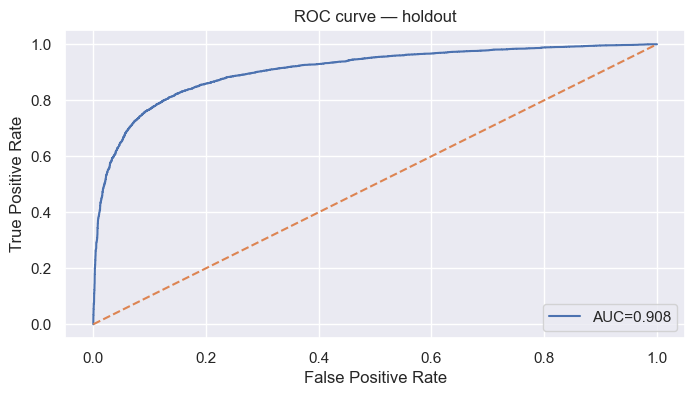

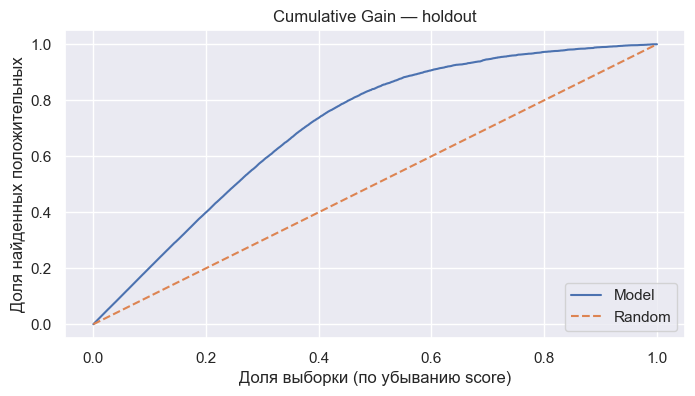

Top-10%: precision=0.985, recall=0.202, lift=2.02x


In [28]:
# ===== 0) Проверки =====
assert 'id' in X.columns, "В X должен быть столбец id для group-split"
print(f"Shape: {X.shape}, positives share: {float(np.mean(y)):.3f}")

# ===== 1) Подготовка X_model / groups =====
groups = X['id'].to_numpy()
X_model = X.drop(columns=['id']).copy()

# Категориальные признаки: берём object + явные кандидаты
cat_cols = X_model.select_dtypes(include=['object']).columns.tolist()
for c in ['education', 'city', 'prod_sex', 'prod_colour_mode', 'product']:
    if c in X_model.columns and c not in cat_cols:
        cat_cols.append(c)

# Если вдруг осталось country — выкидываем (после фильтра обычно константа)
if 'country' in X_model.columns:
    X_model = X_model.drop(columns=['country'])
    cat_cols = [c for c in cat_cols if c != 'country']

# Заполняем пропуски и приводим категории к строкам
for c in cat_cols:
    X_model[c] = X_model[c].fillna('unknown').astype(str)

# Индексы категориальных фич (надёжнее, чем имена)
cat_idx = [X_model.columns.get_loc(c) for c in cat_cols if c in X_model.columns]

print(f"cat_cols ({len(cat_cols)}): {cat_cols}")
print(f"cat_idx: {cat_idx}")

# ===== 2) Holdout по группам (id) =====
gss = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
train_idx, hold_idx = next(gss.split(X_model, y, groups=groups))

X_train = X_model.iloc[train_idx]
y_train = y.iloc[train_idx] if hasattr(y, "iloc") else y[train_idx]
g_train = groups[train_idx]

X_hold = X_model.iloc[hold_idx]
y_hold = y.iloc[hold_idx] if hasattr(y, "iloc") else y[hold_idx]
g_hold = groups[hold_idx]

print(f"Train: {X_train.shape}, Hold: {X_hold.shape}")
print(f"Unique ids train={len(np.unique(g_train))}, hold={len(np.unique(g_hold))}")

# ===== 3) Модель =====
cb = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    allow_writing_files=False,
    thread_count=1,   # чтобы не было переподписки потоков при n_jobs=-1 в RS
    verbose=False
)

# ===== 4) RandomizedSearchCV (CV по группам) =====
param_dist = {
    "iterations": randint(600, 2000),
    "learning_rate": loguniform(0.01, 0.2),
    "depth": randint(4, 10),
    "l2_leaf_reg": loguniform(1.0, 30.0),
    "random_strength": loguniform(1e-3, 10.0),
    "bagging_temperature": uniform(0.0, 10.0),
    "rsm": uniform(0.6, 0.4),
}

cv = GroupKFold(n_splits=5)

rs = RandomizedSearchCV(
    estimator=cb,
    param_distributions=param_dist,
    n_iter=10,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=0,
    error_score="raise"
)

t0 = time.time()
rs.fit(X_train, y_train, groups=g_train, cat_features=cat_idx)
print(f"\nRandomizedSearchCV finished in {time.time()-t0:.1f}s")
print("Best params:", rs.best_params_)
print("Best CV ROC-AUC:", rs.best_score_)

# ===== 5) Holdout оценка =====
best_model = rs.best_estimator_
proba_hold = best_model.predict_proba(X_hold)[:, 1]

auc = roc_auc_score(y_hold, proba_hold)
ap  = average_precision_score(y_hold, proba_hold)
print(f"Holdout ROC-AUC: {auc:.4f}")
print(f"Holdout AP     : {ap:.4f}")

# ROC curve
fpr, tpr, _ = roc_curve(y_hold, proba_hold)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve — holdout")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# ===== 6) Ранжирование (gain/precision@10%/recall@10%/lift@10%) =====
order = np.argsort(-proba_hold)
y_sorted = np.asarray(y_hold)[order]

cum_pos = np.cumsum(y_sorted)
total_pos = max(int(cum_pos[-1]), 1)

x = np.arange(1, len(y_sorted) + 1) / len(y_sorted)
gain = cum_pos / total_pos

plt.figure()
plt.plot(x, gain, label="Model")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("Доля выборки (по убыванию score)")
plt.ylabel("Доля найденных положительных")
plt.title("Cumulative Gain — holdout")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

k = max(int(0.10 * len(y_sorted)), 1)
top_pos = int(cum_pos[k - 1])

precision_k = top_pos / k
recall_k = top_pos / total_pos
base_rate = total_pos / len(y_sorted)
lift_k = precision_k / base_rate

print(f"Top-10%: precision={precision_k:.3f}, recall={recall_k:.3f}, lift={lift_k:.2f}x")


